In [1]:
!pip install sastrawi
!pip install emoji -q

In [2]:
import re
import csv
import requests
import emoji
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from wordcloud import WordCloud

# Machine Learning & Deep Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, LSTM, GRU, Embedding, SpatialDropout1D, Input, GlobalAveragePooling1D, GlobalMaxPooling1D, Dropout, LayerNormalization, MultiHeadAttention, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Configurations
pd.options.mode.chained_assignment = None
SEED = 0
np.random.seed(SEED)
tf.random.set_seed(SEED)

# NLTK Downloads
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
# Memuat dataset ulasan aplikasi JAKI dari berkas CSV hasil scraping
app_reviews_df = pd.read_csv('ulasan_aplikasi_jaki_raw.csv')

jumlah_ulasan, jumlah_kolom = app_reviews_df.shape
print(f"Dataset ulasan berhasil dimuat dari 'ulasan_aplikasi_jaki_raw.csv'! Total: {jumlah_ulasan} baris, {jumlah_kolom} kolom.")

Dataset ulasan berhasil dimuat dari 'ulasan_aplikasi_jaki_raw.csv'! Total: 4919 baris, 11 kolom.


In [4]:
# Menampilkan lima baris pertama dari DataFrame app_reviews_df
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,5b33bbb8-8577-4a50-8e41-722a9af54db6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ini sangat membantu cuma dari saya lihat dan a...,4,2,4.0.22,2026-06-09 17:08:05,Halo Kak Pradana Putra. Terima kasih atas ulas...,2026-06-10 09:31:57,4.0.22
1,28b52e01-674e-4ed7-ad29-6c415cd47524,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Fitur bagus, tampilan juga lumayan ok. Tapi sa...",2,4,4.0.21,2026-06-07 07:01:21,"Hai kak Willy Xplore, mohon maaf atas kendala ...",2026-06-08 09:49:22,4.0.21
2,41e3b0d2-c701-49f8-8bac-c032c390a60d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi bagus, dan sangat membantu utk update...",5,51,4.0.22,2026-06-19 18:42:42,"Hi, Kak Mugi adi. Terima kasih atas ulasannya....",2022-09-07 13:21:53,4.0.22
3,245055e7-0478-466c-a8a6-67ba40ba442c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kenapa pas buka antrian paskes selalu muter2 s...,1,4,4.0.23,2026-07-10 12:18:50,"Hi Kak, mohon maaf atas ketidaknyamanannya, sa...",2026-07-10 19:07:21,4.0.23
4,8cebfae2-c1f3-4dfc-bbd9-1b78a2972e73,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kapan selesainya mau cek pajak masih dalam per...,4,0,4.0.23,2026-07-17 11:58:21,"Halo Kak Sapto, untuk kendala yang kakak alami...",2026-07-17 14:19:19,4.0.23


In [5]:
# Menampilkan informasi tentang DataFrame app_reviews_df
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4919 entries, 0 to 4918
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              4919 non-null   object
 1   userName              4919 non-null   object
 2   userImage             4919 non-null   object
 3   content               4919 non-null   object
 4   score                 4919 non-null   int64 
 5   thumbsUpCount         4919 non-null   int64 
 6   reviewCreatedVersion  3870 non-null   object
 7   at                    4919 non-null   object
 8   replyContent          3240 non-null   object
 9   repliedAt             3240 non-null   object
 10  appVersion            3870 non-null   object
dtypes: int64(2), object(9)
memory usage: 422.9+ KB


In [6]:
# Drop missing values HANYA pada kolom ulasan dan skor
clean_df = app_reviews_df.dropna(subset=['content', 'score']).copy()

In [7]:
# Menghapus baris duplikat dari DataFrame clean_df
clean_df = clean_df.drop_duplicates(subset=['content'])

print(f"Jumlah ulasan awal : {len(app_reviews_df)}")
print(f"Jumlah ulasan bersih: {len(clean_df)}")

# Menghitung jumlah baris dan kolom dalam DataFrame clean_df setelah menghapus duplikat
jumlah_ulasan_setelah_hapus_duplikat, jumlah_kolom_setelah_hapus_duplikat = clean_df.shape

Jumlah ulasan awal : 4919
Jumlah ulasan bersih: 4123


In [8]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4123 entries, 0 to 4918
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              4123 non-null   object
 1   userName              4123 non-null   object
 2   userImage             4123 non-null   object
 3   content               4123 non-null   object
 4   score                 4123 non-null   int64 
 5   thumbsUpCount         4123 non-null   int64 
 6   reviewCreatedVersion  3325 non-null   object
 7   at                    4123 non-null   object
 8   replyContent          2784 non-null   object
 9   repliedAt             2784 non-null   object
 10  appVersion            3325 non-null   object
dtypes: int64(2), object(9)
memory usage: 386.5+ KB


In [9]:
# Inisialisasi objek Stemmer dan daftar Stopwords secara global untuk efisiensi komputasi
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Penggabungan korpus stopword Bahasa Indonesia dan Inggris serta penambahan entri kustom
listStopwords = set(stopwords.words('indonesian')).union(set(stopwords.words('english')))
listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])

kata_negasi_dan_penguat = {'tidak', 'bukan', 'belum', 'kurang', 'jangan', 'sangat', 'banget', 'sekali'}
listStopwords = listStopwords - kata_negasi_dan_penguat

def convert_emojis(text):
    """
    Mentransformasi karakter emoji menjadi representasi tekstual sentimen dalam Bahasa Indonesia.
    """
    emoji_dict = {
        '👍': ' bagus ', '👎': ' buruk ', '😊': ' senang ', '🙂': ' senang ',
        '☺️': ' senang ', '😍': ' suka ', '❤️': ' suka ', '😭': ' sedih ',
        '😢': ' sedih ', '😡': ' marah ', '🤬': ' marah ', '😒': ' buruk ',
        '🙏': ' terima kasih ', '🤮': ' buruk '
    }

    for emo, text_rep in emoji_dict.items():
        text = text.replace(emo, text_rep)

    # Menghapus emoji yang tidak terdefinisi dalam kamus kustom untuk mengurangi noise
    text = emoji.replace_emoji(text, replace='')
    return text

def cleaningText(text):
    # Tahap pembersihan teks menggunakan Regular Expression (Regex)
    text = convert_emojis(text)
    text = re.sub(r'@[A-Za-z0-9_]+', '', text) # Menghapus mention
    text = re.sub(r'#[A-Za-z0-9_]+', '', text) # Menghapus hashtag
    text = re.sub(r'RT[\s]', '', text)        # Menghapus simbol Re-Tweet
    text = re.sub(r"http\S+|www\S+", '', text)# Menghapus tautan URL
    text = re.sub(r'[0-9]+', '', text)        # Menghapus karakter numerik
    text = re.sub(r'[^\w\s]', '', text)       # Menghapus tanda baca dan simbol non-alfanumerik
    text = text.replace('\n', ' ')            # Normalisasi whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def casefoldingText(text):
    # Standarisasi teks menjadi huruf kecil (lowercase)
    return text.lower()

def tokenizingText(text):
    # Pemecahan kalimat menjadi urutan token kata
    return word_tokenize(text)

def filteringText(text):
    # Eliminasi kata-kata fungsional (stopwords) yang tidak memiliki nilai informatif signifikan
    return [txt for txt in text if txt not in listStopwords]

def stemmingText(text):
    # Transformasi kata menjadi bentuk dasar (root word)
    if isinstance(text, list):
        text = ' '.join(text)
    return stemmer.stem(text)

def toSentence(list_words):
    # Penggabungan kembali token kata menjadi struktur kalimat
    return ' '.join(list_words)

In [10]:
# Kamus pemetaan kata tidak baku (slang) ke bentuk formal Bahasa Indonesia
# Berguna untuk meningkatkan akurasi ekstraksi fitur dan pemahaman konteks oleh model
slangwords = {
    # Kategori: Singkatan Umum
    "utk": "untuk", "yg": "yang", "apk": "aplikasi", "pas": "saat", "dgn": "dengan",
    "sbg": "sebagai", "klo": "kalau", "kalo": "kalau", "kl": "kalau", "sm": "sama",
    "sdh": "sudah", "udh": "sudah", "blm": "belum", "tdk": "tidak", "tp": "tapi",
    "dri": "dari", "brp": "berapa", "krn": "karena", "sy": "saya",

    # Kategori: Negasi dan Sentimen Khusus
    "abis": "habis", "masi": "masih", "bgt": "banget", "ga": "tidak", "gak": "tidak",
    "nggak": "tidak", "gk": "tidak", "gabisa": "tidak bisa", "gajelas": "tidak jelas",

    # Kategori: Domain-Specific (Aplikasi JAKI)
    "lemot": "lambat", "eror": "error", "verif": "verifikasi", "respon": "tanggapan",
    "fastrespon": "tanggapan cepat", "mantul": "bagus"
}

def fix_slangwords(text):
    """
    Mengganti kata-kata non-formal berdasarkan kamus 'slangwords'.
    Melakukan pengecekan case-insensitive.
    """
    words = text.split()
    fixed_words = [slangwords.get(word.lower(), word) for word in words]
    return ' '.join(fixed_words)

In [11]:
# 1. Cleaning awal
clean_df['text_clean'] = clean_df['content'].astype(str).apply(cleaningText)

# 2. Lowercase / Casefolding
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# 3. Penanganan kata slang
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# 4. Tokenisasi
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# 5. Stopword removal
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# 6. Menggabungkan kembali menjadi kalimat akhir
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [12]:
clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,5b33bbb8-8577-4a50-8e41-722a9af54db6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ini sangat membantu cuma dari saya lihat dan a...,4,2,4.0.22,2026-06-09 17:08:05,Halo Kak Pradana Putra. Terima kasih atas ulas...,2026-06-10 09:31:57,4.0.22,ini sangat membantu cuma dari saya lihat dan a...,ini sangat membantu cuma dari saya lihat dan a...,ini sangat membantu cuma dari saya lihat dan a...,"[ini, sangat, membantu, cuma, dari, saya, liha...","[sangat, membantu, lihat, amati, kayak, lapora...",sangat membantu lihat amati kayak laporan warg...
1,28b52e01-674e-4ed7-ad29-6c415cd47524,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Fitur bagus, tampilan juga lumayan ok. Tapi sa...",2,4,4.0.21,2026-06-07 07:01:21,"Hai kak Willy Xplore, mohon maaf atas kendala ...",2026-06-08 09:49:22,4.0.21,Fitur bagus tampilan juga lumayan ok Tapi saya...,fitur bagus tampilan juga lumayan ok tapi saya...,fitur bagus tampilan juga lumayan ok tapi saya...,"[fitur, bagus, tampilan, juga, lumayan, ok, ta...","[fitur, bagus, tampilan, lumayan, ok, sayang, ...",fitur bagus tampilan lumayan ok sayang ngelag ...
2,41e3b0d2-c701-49f8-8bac-c032c390a60d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi bagus, dan sangat membantu utk update...",5,51,4.0.22,2026-06-19 18:42:42,"Hi, Kak Mugi adi. Terima kasih atas ulasannya....",2022-09-07 13:21:53,4.0.22,Aplikasi bagus dan sangat membantu utk update ...,aplikasi bagus dan sangat membantu utk update ...,aplikasi bagus dan sangat membantu untuk updat...,"[aplikasi, bagus, dan, sangat, membantu, untuk...","[aplikasi, bagus, sangat, membantu, update, ja...",aplikasi bagus sangat membantu update jakarta ...
3,245055e7-0478-466c-a8a6-67ba40ba442c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kenapa pas buka antrian paskes selalu muter2 s...,1,4,4.0.23,2026-07-10 12:18:50,"Hi Kak, mohon maaf atas ketidaknyamanannya, sa...",2026-07-10 19:07:21,4.0.23,kenapa pas buka antrian paskes selalu muter su...,kenapa pas buka antrian paskes selalu muter su...,kenapa saat buka antrian paskes selalu muter s...,"[kenapa, saat, buka, antrian, paskes, selalu, ...","[buka, antrian, paskes, muter, pakai, jaringan...",buka antrian paskes muter pakai jaringan g wif...
4,8cebfae2-c1f3-4dfc-bbd9-1b78a2972e73,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kapan selesainya mau cek pajak masih dalam per...,4,0,4.0.23,2026-07-17 11:58:21,"Halo Kak Sapto, untuk kendala yang kakak alami...",2026-07-17 14:19:19,4.0.23,kapan selesainya mau cek pajak masih dalam per...,kapan selesainya mau cek pajak masih dalam per...,kapan selesainya mau cek pajak masih dalam per...,"[kapan, selesainya, mau, cek, pajak, masih, da...","[selesainya, cek, pajak, perbaikan, sistem]",selesainya cek pajak perbaikan sistem
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4914,6211cd65-1ae4-4bf2-a4ae-cb9a03c91599,Zaenal Abidin,https://play-lh.googleusercontent.com/a-/ALV-U...,Terimakasih...... 🙏🏻🙏🏻🙏🏻🙏🏻🙏🏻🙏🏻🙏🏻🙏🏻🙏🏻🙏🏻,5,0,NaN,2024-05-23 01:01:19,"Hi, Kak Zaenal Abidin. Terima kasih telah memb...",2024-05-29 13:58:33,NaN,Terimakasih terima kasih terima kasih terima k...,terimakasih terima kasih terima kasih terima k...,terimakasih terima kasih terima kasih terima k...,"[terimakasih, terima, kasih, terima, kasih, te...","[terimakasih, terima, kasih, terima, kasih, te...",terimakasih terima kasih terima kasih terima k...
4915,ee6e9da8-9e3b-4524-8880-990c9a4cb15f,Mung Dwi.p,https://play-lh.googleusercontent.com/a-/ALV-U...,Mantap 👍👍👍👍👍👍👍👍,5,0,NaN,2021-07-06 20:36:36,"Hi kak, Terima kasih atas ulasannya ya. Kami a...",2021-07-07 09:33:51,NaN,Mantap bagus bagus bagus bagus bagus bagus bag...,mantap bagus bagus bagus bagus bagus bagus bag...,mantap bagus b

In [13]:
# --- Inisialisasi Kamus Leksikon Sentimen ---
lexicon_positive = dict()
lexicon_negative = dict()

# 1. Memuat korpus kata positif & negatif dari repositori eksternal (GitHub)
url_pos = 'https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv'
response_pos = requests.get(url_pos)
if response_pos.status_code == 200:
    reader = csv.reader(StringIO(response_pos.text), delimiter=',')
    for row in reader:
        lexicon_positive[row[0]] = int(row[1])

url_neg = 'https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv'
response_neg = requests.get(url_neg)
if response_neg.status_code == 200:
    reader = csv.reader(StringIO(response_neg.text), delimiter=',')
    for row in reader:
        lexicon_negative[row[0]] = int(row[1])

# 2. Penyesuaian Leksikon Negatif (Filtering Anomali Kata)
# Daftar kata anomali yang salah masuk ke dataset negatif di GitHub tersebut
kata_bocor = [
    'bagus', 'senang', 'baik', 'suka', 'cinta', 'indah',
    'sayang', 'kasih', 'manis', 'ceria', 'suci', 'untung'
]

# Hapus kata-kata di atas dari lexicon_negative agar tidak merusak skor
for kata in kata_bocor:
    if kata in lexicon_negative:
        del lexicon_negative[kata]

print(f"Total kata positif: {len(lexicon_positive)}")
print(f"Total kata negatif setelah dikoreksi: {len(lexicon_negative)}")

Total kata positif: 3609
Total kata negatif setelah dikoreksi: 6595


In [14]:
# Fungsi untuk menentukan polaritas sentimen dari teks ulasan

def sentiment_analysis_lexicon_indonesia(text):
    score = 0
    for word in text:
        if word in lexicon_positive:
            score += lexicon_positive[word]
        if word in lexicon_negative:
            score += lexicon_negative[word]

    # Pengkondisian yang benar untuk 3 kelas
    if score > 0:
        polarity = 'positive'
    elif score < 0:
        polarity = 'negative'
    else:
        polarity = 'neutral'  # Skor 0 akan masuk ke sini

    return score, polarity

In [15]:
# --- Eksekusi Pelabelan Sentimen Otomatis ---
# Menerapkan fungsi lexicon-based analysis pada kolom teks yang telah dibersihkan
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)

# Memisahkan hasil tuple (score, polarity) ke dalam kolom DataFrame yang berbeda
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]

# Menampilkan distribusi label sentimen untuk memverifikasi keseimbangan data
print("Distribusi Sentimen Hasil Pelabelan Leksikon:")
print(clean_df['polarity'].value_counts())

Distribusi Sentimen Hasil Pelabelan Leksikon:
polarity
negative    2587
positive    1016
neutral      520
Name: count, dtype: int64


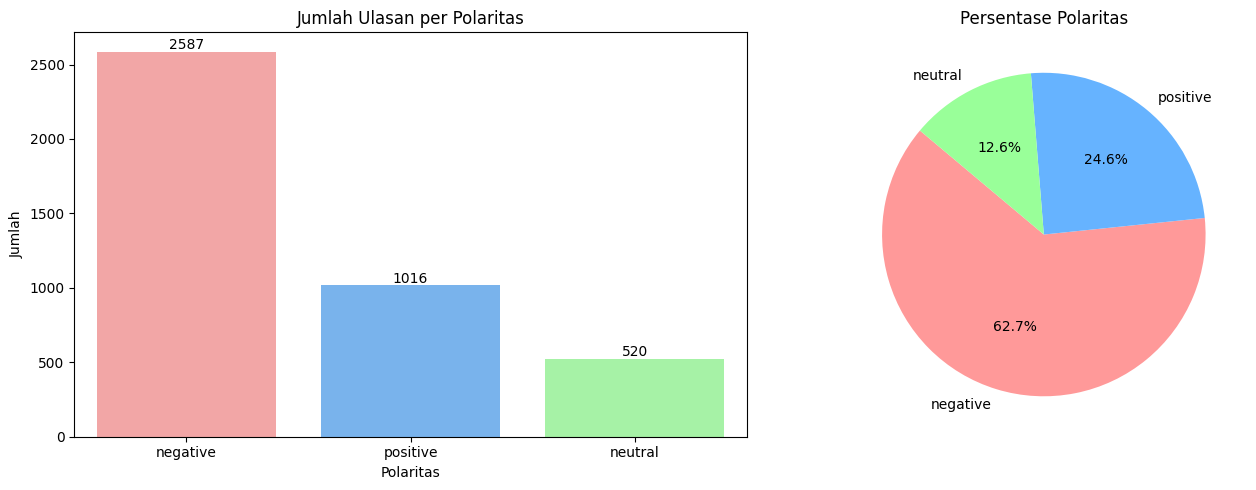

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Definisi 3 warna untuk 3 kelas (misal: Negatif=Merah/Pink, Netral=Abu-abu, Positif=Biru)
colors = ['#ff9999', '#66b3ff', '#99ff99']

# 1. Bar Chart
sns.countplot(ax=axes[0], x='polarity', data=clean_df, hue='polarity', palette=colors, legend=False)
axes[0].set_title('Jumlah Ulasan per Polaritas')
axes[0].set_xlabel('Polaritas')
axes[0].set_ylabel('Jumlah')

# Menambahkan angka jumlah di atas setiap batang
for p in axes[0].patches:
    if p.get_height() > 0:
        axes[0].annotate(f'{int(p.get_height())}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center',
                        xytext=(0, 5),
                        textcoords='offset points')

# 2. Pie Chart
counts = clean_df['polarity'].value_counts()
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
axes[1].set_title('Persentase Polaritas')

plt.tight_layout()
plt.show()

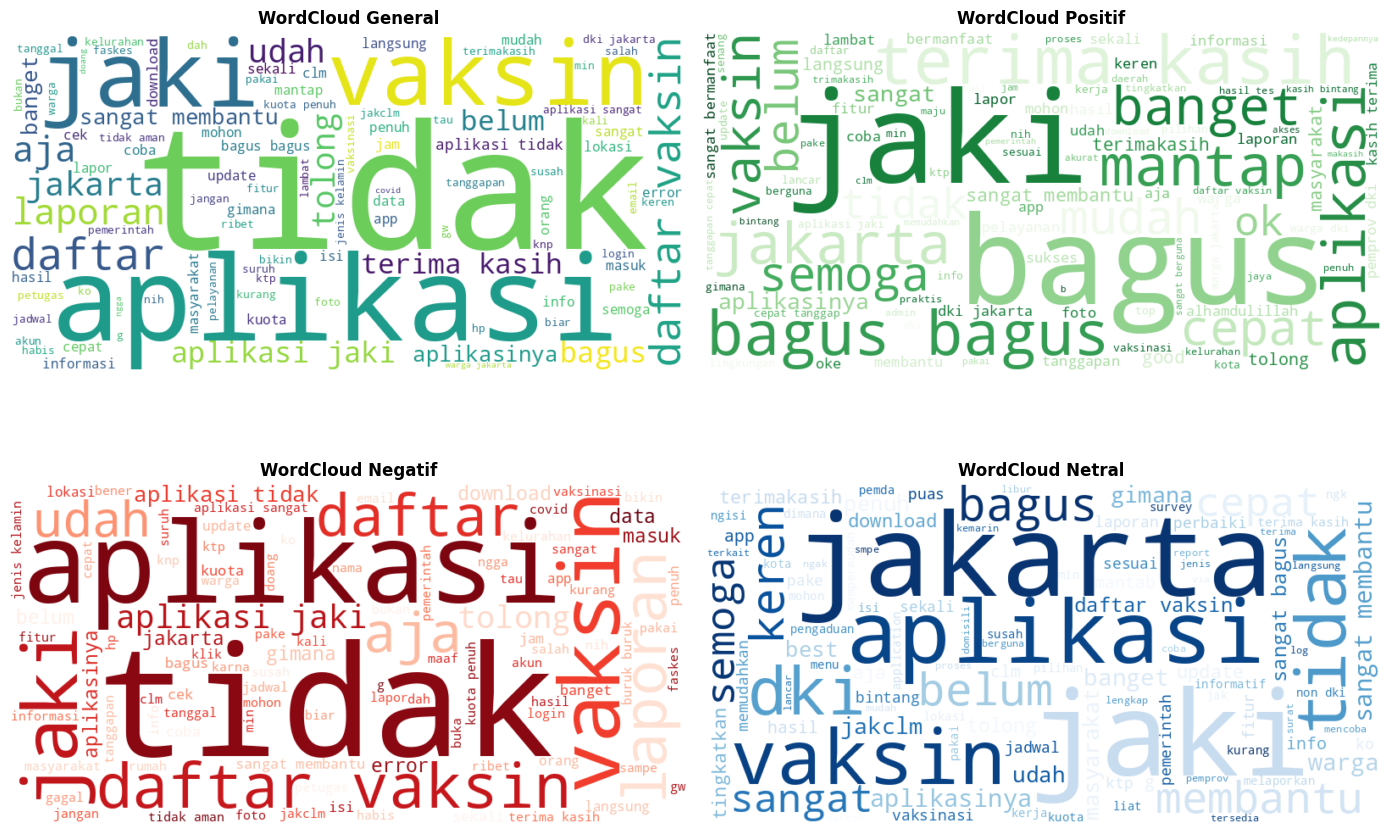

In [17]:
# 1. Menyiapkan teks untuk masing-masing tipe (4 tipe)
text_general = ' '.join(clean_df['text_akhir'].dropna())
text_positive = ' '.join(clean_df[clean_df['polarity'] == 'positive']['text_akhir'].dropna())
text_negative = ' '.join(clean_df[clean_df['polarity'] == 'negative']['text_akhir'].dropna())
text_neutral = ' '.join(clean_df[clean_df['polarity'] == 'neutral']['text_akhir'].dropna())

# 2. Pengaturan Parameter WordCloud
wc_general = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap='viridis').generate(text_general)
wc_positive = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap='Greens').generate(text_positive)
wc_negative = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap='Reds').generate(text_negative)
wc_neutral = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap='Blues').generate(text_neutral)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subplot 1: General (Kiri Atas)
axes[0, 0].imshow(wc_general, interpolation='bilinear')
axes[0, 0].set_title('WordCloud General', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Subplot 2: Positif (Kanan Atas)
axes[0, 1].imshow(wc_positive, interpolation='bilinear')
axes[0, 1].set_title('WordCloud Positif', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

# Subplot 3: Negatif (Kiri Bawah)
axes[1, 0].imshow(wc_negative, interpolation='bilinear')
axes[1, 0].set_title('WordCloud Negatif', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

# Subplot 4: Netral (Kanan Bawah)
axes[1, 1].imshow(wc_neutral, interpolation='bilinear')
axes[1, 1].set_title('WordCloud Netral', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [18]:
# ==========================================================
# 1. TAHAP EKSTRAKSI FITUR (FEATURE ENGINEERING)
# ==========================================================

# Implementasi representasi teks menggunakan TF-IDF Vectorizer
# Menggunakan konfigurasi optimal (max_features dinaikkan & sublinear_tf=True)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=3, sublinear_tf=True)
X_tfidf_array = tfidf.fit_transform(clean_df['text_akhir']).toarray()
X_tfidf = pd.DataFrame(X_tfidf_array, columns=tfidf.get_feature_names_out())

# Transformasi label kategori menjadi representasi numerik untuk pemodelan
le = LabelEncoder()
y_encoded = le.fit_transform(clean_df['polarity'])
num_classes = len(le.classes_)


# ==========================================================
# 2. PREPARASI DATA UNTUK ARSITEKTUR DEEP LEARNING (SEQUENCE)
# ==========================================================
MAX_WORDS = 5000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, split=' ')
tokenizer.fit_on_texts(clean_df['text_akhir'].values)
X_seq = tokenizer.texts_to_sequences(clean_df['text_akhir'].values)
X_pad = pad_sequences(X_seq, maxlen=MAX_LEN)

# --- A. Arsitektur LSTM ---
def build_lstm_model():
    model = Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=128),
        SpatialDropout1D(0.2),
        LSTM(64, dropout=0.2, recurrent_dropout=0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# --- B. Arsitektur GRU ---
def build_gru_model():
    model = Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=128),
        SpatialDropout1D(0.2),
        GRU(64, dropout=0.2, recurrent_dropout=0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# --- C. Arsitektur Transformer (Self-Attention) ---
class TokenAndPositionEmbedding(tf.keras.layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.token_emb = Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

# --- D. Arsitektur BiLSTM ---
def build_bilstm_model():
    model = Sequential(
        [
            Embedding(
                input_dim=MAX_WORDS, output_dim=128),
            SpatialDropout1D(0.3),
            Bidirectional(
                LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)
            ),
            GlobalMaxPooling1D(),
            Dense(32, activation="relu"),
            Dropout(0.4),
            Dense(num_classes, activation="softmax"),
        ]
    )
    model.compile(
        loss="categorical_crossentropy",
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        metrics=["accuracy"],
    )
    return model

def build_transformer_model():
    embed_dim = 128  # Ukuran embedding
    num_heads = 2    # Jumlah attention head
    ff_dim = 64      # Ukuran hidden layer di feed forward network

    inputs = Input(shape=(MAX_LEN,))
    embedding_layer = TokenAndPositionEmbedding(MAX_LEN, MAX_WORDS, embed_dim)(inputs)

    # Transformer Block
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(embedding_layer, embedding_layer)
    attn_output = Dropout(0.1)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(embedding_layer + attn_output)

    ffn_output = Dense(ff_dim, activation="relu")(out1)
    ffn_output = Dense(embed_dim)(ffn_output)
    ffn_output = Dropout(0.1)(ffn_output)
    out2 = LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

    x = GlobalAveragePooling1D()(out2)
    x = Dropout(0.1)(x)
    x = Dense(32, activation="relu")(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


# ==========================================================
# 3. KONFIGURASI DAN EKSEKUSI EKSPERIMEN MODEL
# ==========================================================
experiments = [
    # --- Kelompok Fitur TF-IDF ---
    {
        "nama": "Eksperimen 1",
        "model_name": "Logistic Regression (TF-IDF)",
        "model": LogisticRegression(C=2.0, max_iter=1000, class_weight='balanced', random_state=42),
        "feature_type": "TF-IDF",
        "X": X_tfidf,
        "test_size": 0.2,
        "is_nn": False
    },
    {
        "nama": "Eksperimen 2",
        "model_name": "SVM (TF-IDF)",
        "model": SVC(kernel='linear', C=1.5, class_weight='balanced', random_state=42),
        "feature_type": "TF-IDF",
        "X": X_tfidf,
        "test_size": 0.2,
        "is_nn": False
    },
    {
        "nama": "Eksperimen 3",
        "model_name": "LightGBM (TF-IDF)",
        "model": LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1),
        "feature_type": "TF-IDF",
        "X": X_tfidf,
        "test_size": 0.2,
        "is_nn": False
    },
    {
        "nama": "Eksperimen 4",
        "model_name": "LinearSVC (TF-IDF)",
        "model": LinearSVC(C=0.5, class_weight='balanced', random_state=42),
        "feature_type": "TF-IDF",
        "X": X_tfidf,
        "test_size": 0.2,
        "is_nn": False
    },

    # --- Kelompok Deep Learning (Sequence) ---
    {
        "nama": "Eksperimen 5",
        "model_name": "LSTM (Sequence)",
        "model": build_lstm_model(),
        "feature_type": "Sequence Tokenizer",
        "X": X_pad,
        "test_size": 0.2,
        "is_nn": True
    },
    {
        "nama": "Eksperimen 6",
        "model_name": "GRU (Sequence)",
        "model": build_gru_model(),
        "feature_type": "Sequence Tokenizer",
        "X": X_pad,
        "test_size": 0.2,
        "is_nn": True
    },
    {
        "nama": "Eksperimen 7",
        "model_name": "Transformer (Self-Attention)",
        "model": build_transformer_model(),
        "feature_type": "Sequence Tokenizer",
        "X": X_pad,
        "test_size": 0.2,
        "is_nn": True
    },
    {
        "nama": "Eksperimen 8",
        "model_name": "BiLSTM (Sequence)",
        "model": build_bilstm_model(),
        "feature_type": "Sequence Tokenizer",
        "X": X_pad,
        "test_size": 0.2,
        "is_nn": True,
    },
]


# Evaluasi performa model berdasarkan metrik akurasi
results = []
for exp in experiments:
    X_train, X_test, y_train, y_test = train_test_split(
        exp['X'], y_encoded, test_size=exp['test_size'], random_state=42, stratify=y_encoded
    )

    if exp.get('is_nn', False):
        y_train_nn = to_categorical(y_train, num_classes)
        model = exp['model']
        model.fit(X_train, y_train_nn, epochs=5, batch_size=32, verbose=0)
        y_pred_train = np.argmax(model.predict(X_train, verbose=0), axis=1)
        y_pred_test = np.argmax(model.predict(X_test, verbose=0), axis=1)
    else:
        model = exp['model']
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    results.append({
        "Model": exp['model_name'],
        "Fitur": exp['feature_type'],
        "Akurasi Latih": round(acc_train, 4),
        "Akurasi Uji": round(acc_test, 4)
    })

# Visualisasi tabel hasil perbandingan performa
display(pd.DataFrame(results).sort_values(by="Akurasi Uji", ascending=False).reset_index(drop=True))

,Model,Fitur,Akurasi Latih,Akurasi Uji
0,BiLSTM (Sequence),Sequence Tokenizer,0.9682,0.8836
1,Transformer (Self-Attention),Sequence Tokenizer,0.9700,0.8788
2,LSTM (Sequence),Sequence Tokenizer,0.9803,0.8752
3,GRU (Sequence),Sequence Tokenizer,0.9818,0.8703
4,LinearSVC (TF-IDF),TF-IDF,0.9812,0.8691
5,SVM (TF-IDF),TF-IDF,0.9660,0.8642
6,Logistic Regression (TF-IDF),TF-IDF,0.9600,0.8509
7,LightGBM (TF-IDF),TF-IDF,0.9254,0.8327


In [19]:
# ==========================================
# BLOK INFERENCE / TESTING DATA BARU (MODEL TERBAIK)
# ==========================================

# Mengambil model dengan akurasi tertinggi: Transformer (Self-Attention)
# Berdasarkan list 'experiments', model ini berada di index 6
best_model_index = 6
model_terbaik = experiments[best_model_index]['model']

def prediksi_sentimen(teks_baru, model_terlatih, tokenizer_obj, label_encoder, max_len):
    """
    Fungsi untuk melakukan inference pada teks ulasan baru.
    Menghasilkan output kelas kategorikal (positive, negative, neutral).
    """
    # 1. Preprocessing teks baru (memanggil fungsi-fungsi dari cell sebelumnya)
    teks = cleaningText(teks_baru)
    teks = casefoldingText(teks)
    teks = fix_slangwords(teks)
    teks = tokenizingText(teks)
    teks = filteringText(teks)
    teks_bersih = toSentence(teks)

    # 2. Tokenisasi & Padding (Sesuai format input model Deep Learning)
    seq = tokenizer_obj.texts_to_sequences([teks_bersih])
    pad_seq = pad_sequences(seq, maxlen=max_len)

    # 3. Proses Inference (Prediksi probabilitas)
    pred_prob = model_terlatih.predict(pad_seq, verbose=0)

    # 4. Konversi ke Kelas Kategorikal
    pred_class_idx = np.argmax(pred_prob, axis=1)
    kategori_sentimen = label_encoder.inverse_transform(pred_class_idx)[0]

    return kategori_sentimen

# ==========================================
# TESTING DENGAN KALIMAT BARU
# ==========================================
print("--- MENGGUNAKAN MODEL TERBAIK: Transformer (Self-Attention) ---\n")

# Contoh 1: Ulasan Positif
ulasan_1 = "Aplikasi ini sangat bagus dan ngebantu banget. Mantap JAKI!"
# Menggunakan variabel 'tokenizer', 'le', dan 'MAX_LEN' dari sel sebelumnya
hasil_1 = prediksi_sentimen(ulasan_1, model_terbaik, tokenizer, le, MAX_LEN)
print(f"Ulasan   : '{ulasan_1}'\nPrediksi : {hasil_1}\n")

# Contoh 2: Ulasan Negatif
ulasan_2 = "Gimana sih ini apk lemot banget, pas mau verifikasi ktp muter muter terus gajelas"
hasil_2 = prediksi_sentimen(ulasan_2, model_terbaik, tokenizer, le, MAX_LEN)
print(f"Ulasan   : '{ulasan_2}'\nPrediksi : {hasil_2}\n")

# Contoh 3: Ulasan Netral
ulasan_3 = "Sudah saya download dan diinstall di hp saya untuk coba lapor. laporan saya langsung di proses"
hasil_3 = prediksi_sentimen(ulasan_3, model_terbaik, tokenizer, le, MAX_LEN)
print(f"Ulasan   : '{ulasan_3}'\nPrediksi : {hasil_3}")

--- MENGGUNAKAN MODEL TERBAIK: Transformer (Self-Attention) ---

Ulasan   : 'Aplikasi ini sangat bagus dan ngebantu banget. Mantap JAKI!'
Prediksi : positive

Ulasan   : 'Gimana sih ini apk lemot banget, pas mau verifikasi ktp muter muter terus gajelas'
Prediksi : negative

Ulasan   : 'Sudah saya download dan diinstall di hp saya untuk coba lapor. laporan saya langsung di proses'
Prediksi : positive
